In [74]:
# Import Library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [75]:
# Load Dataset
df = pd.read_csv('../data/house_prices_dataset.csv')

# Preview Dataset
df.sample(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
187,188,50,RL,60.0,10410,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,135000
55,56,20,RL,100.0,10175,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,180500
762,763,60,FV,72.0,8640,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,Con,Normal,215200
89,90,20,RL,60.0,8070,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,123600
477,478,60,RL,105.0,13693,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,380000
822,823,60,RL,NaN,12394,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2007,WD,Family,225000
954,955,90,RL,35.0,9400,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,AdjLand,127500
933,934,20,RL,63.0,8487,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,WD,Normal,190000
820,821,60,RL,72.0,7226,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,183000
1296,1297,20,RL,80.0,8700,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,12,2008,WD,Normal,155000


In [73]:
# Identifikasi Karakteristik Dataset
print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")
print(f"Total Duplikat: {df.duplicated().sum()}")

Jumlah Baris : 1460
Jumlah Kolom : 81
Total Duplikat: 0


# Exploratory Data Analysis

In [59]:
# Identifikasi Kolom Numerik dan Kategorikal Pada Dataset
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Kolom 'Id' Bukan Feature Analisis, 
if "Id" in num_cols:
    num_cols.remove("Id")

print(f"\nJumlah Fitur Numerik   : {len(num_cols)}")
print(f"Jumlah Fitur Kategorikal: {len(cat_cols)}")


Jumlah Fitur Numerik   : 37
Jumlah Fitur Kategorikal: 43


C:\Users\Hassan\AppData\Local\Temp\ipykernel_7140\2295199771.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_series.head(15).index, y=null_series.head(15).values, palette="viridis")


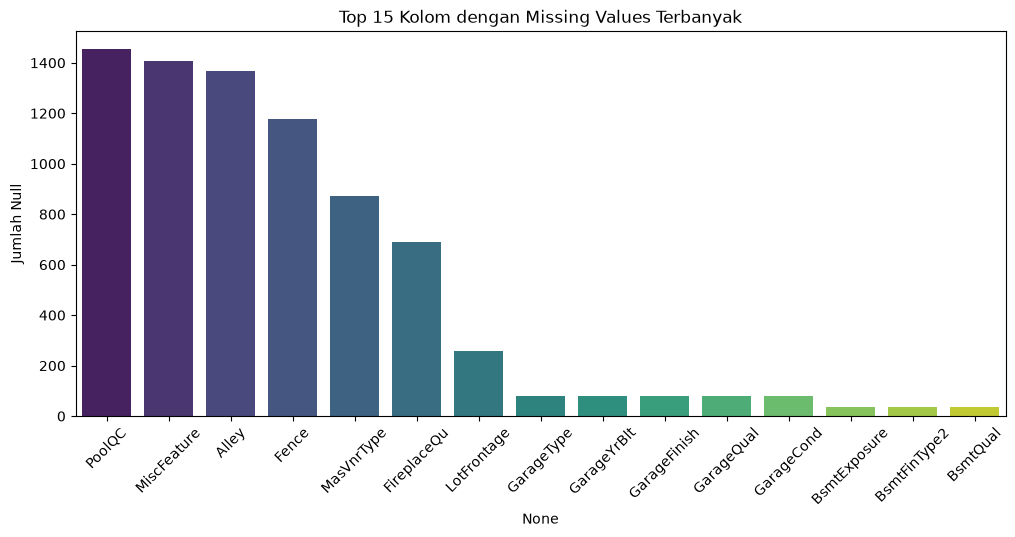

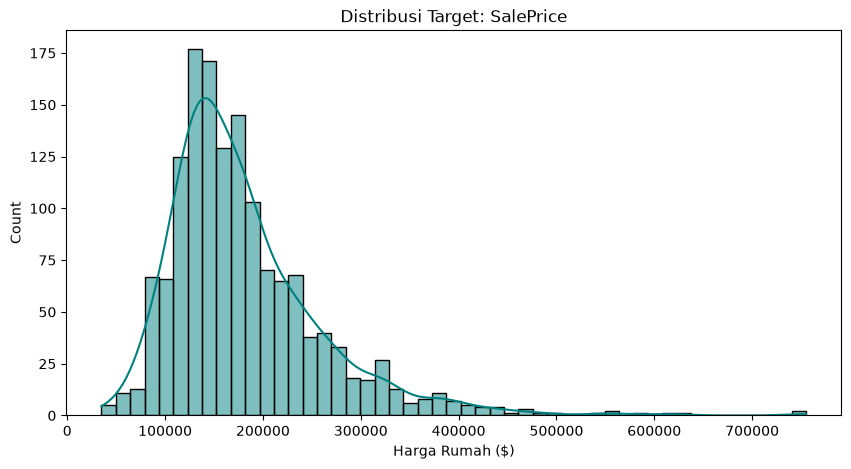

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [60]:
# Cek missing values tertinggi
null_series = df.isnull().sum()
null_series = null_series[null_series > 0].sort_values(ascending=False)

if not null_series.empty:
    plt.figure(figsize=(12, 5))
    sns.barplot(x=null_series.head(15).index, y=null_series.head(15).values, palette="viridis")
    plt.xticks(rotation=45)
    plt.title("Top 15 Kolom dengan Missing Values Terbanyak")
    plt.ylabel("Jumlah Null")
    plt.show()

# Distribusi Target Variable (SalePrice)
plt.figure(figsize=(10, 5))
sns.histplot(df["SalePrice"], kde=True, color="teal")
plt.title("Distribusi Target: SalePrice")
plt.xlabel("Harga Rumah ($)")
plt.show()

print(df["SalePrice"].describe())

10 Fitur dengan Korelasi Positif Tertinggi:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

5 Fitur dengan Korelasi Terendah/Negatif:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


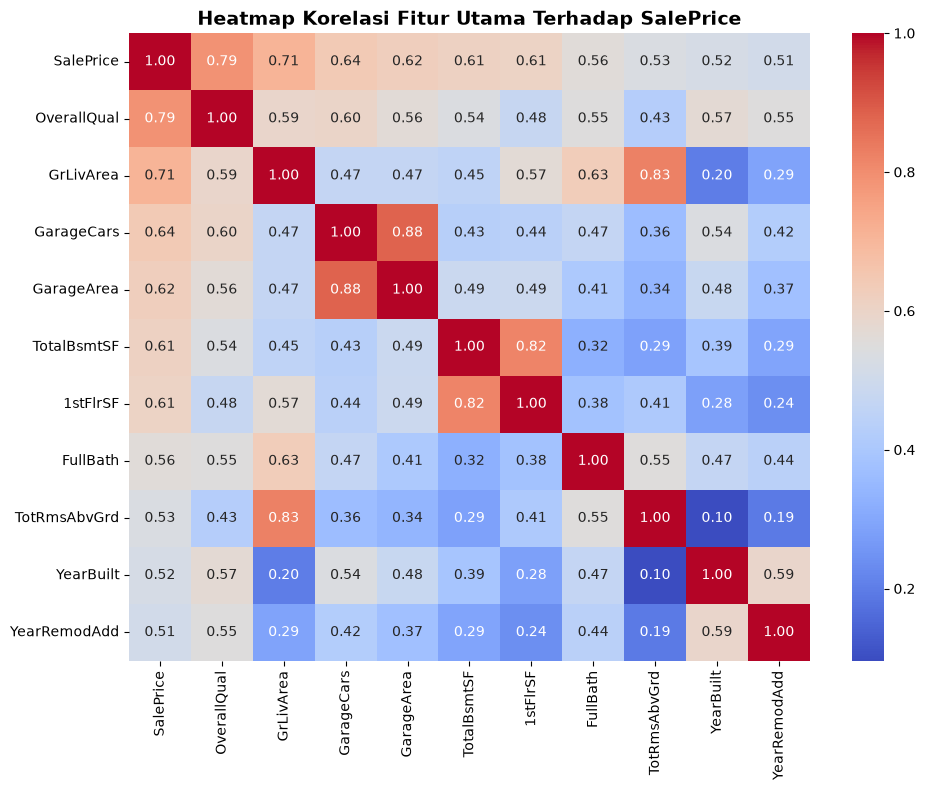

In [61]:
# Membuat Visualisasi Analisis Korelasi
correlations = df[num_cols].corr()["SalePrice"].sort_values(ascending=False)
print("10 Fitur dengan Korelasi Positif Tertinggi:")
print(correlations.head(11))

print("\n5 Fitur dengan Korelasi Terendah/Negatif:")
print(correlations.tail(5))

# Heatmap Top 10 Correlations
top_corr_cols = correlations.head(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi Fitur Utama Terhadap SalePrice", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Hassan\AppData\Local\Temp\ipykernel_7140\3826777031.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="OverallQual", y="SalePrice", data=df, ax=axes[0, 0], palette="Blues")
C:\Users\Hassan\AppData\Local\Temp\ipykernel_7140\3826777031.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Neighborhood", y="SalePrice", data=df, order=top_neigh, ax=axes[1, 1], palette="Set3")
C:\Users\Hassan\AppData\Local\Temp\ipykernel_7140\3826777031.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)


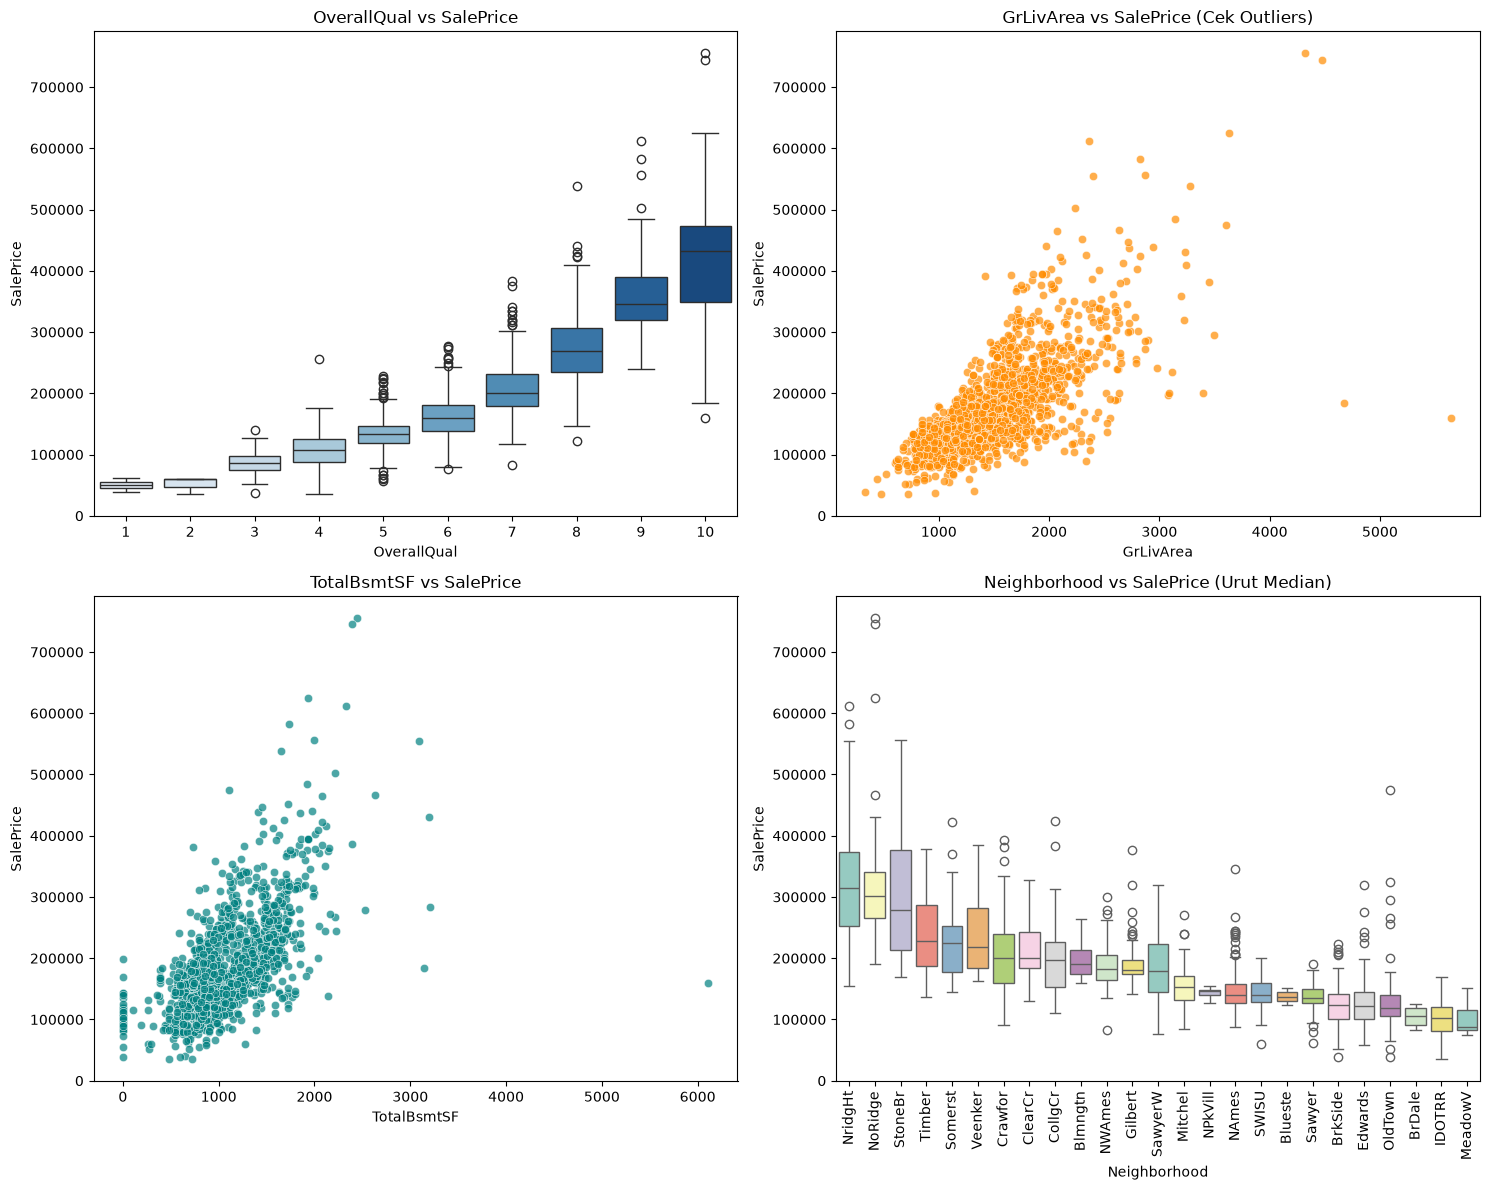

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Visualisasi OverallQual vs SalePrice
sns.boxplot(x="OverallQual", y="SalePrice", data=df, ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("OverallQual vs SalePrice", fontsize=12)

# Visualisasi GrLivArea vs SalePrice (Scatter & Outliers)
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df, ax=axes[0, 1], alpha=0.7, color="darkorange")
axes[0, 1].set_title("GrLivArea vs SalePrice (Cek Outliers)", fontsize=12)

# Visualisasi TotalBsmtSF vs SalePrice
sns.scatterplot(x="TotalBsmtSF", y="SalePrice", data=df, ax=axes[1, 0], alpha=0.7, color="teal")
axes[1, 0].set_title("TotalBsmtSF vs SalePrice", fontsize=12)

# Visualisasi Neighborhood vs SalePrice
top_neigh = df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index
sns.boxplot(x="Neighborhood", y="SalePrice", data=df, order=top_neigh, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=90)
axes[1, 1].set_title("Neighborhood vs SalePrice (Urut Median)", fontsize=12)

plt.tight_layout()
plt.show()

In [63]:
# Identifikasi Outlier
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print(f"Jumlah outlier signifikan terdeteksi: {len(outliers)}")
if len(outliers) > 0:
    print(outliers[["Id", "GrLivArea", "OverallQual", "SalePrice"]])

Jumlah outlier signifikan terdeteksi: 2
        Id  GrLivArea  OverallQual  SalePrice
523    524       4676           10     184750
1298  1299       5642           10     160000


# Split Dataset

In [64]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")

Ukuran X_train: (1168, 80)
Ukuran X_test : (292, 80)


# Data Preprocessing

In [65]:
# Menentukan Kolom Numerik dan Kategorikal Pada Data Train
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Pipeline Preprocessing Numerik (Median Imputation + Scaling)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline Preprocessing Kategorikal (Mode Imputation + One-Hot Encoding)
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Menggabungkan Preprocessor
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Fit & Transform pada data train, Transform pada data test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Bentuk data setelah preprocessing: {X_train_prep.shape}")

Bentuk data setelah preprocessing: (1168, 286)


# Model Training & Evaluation

In [68]:
# Menentukan Model Machine Learning
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Lasso Regression": Lasso(alpha=1.0, max_iter=10000, random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Melakukan Model Training
trained_models = {}

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    trained_models[name] = model
    print(f"Model {name} telah selesai dilatih.")

Model Linear Regression telah selesai dilatih.
Model Ridge Regression telah selesai dilatih.
Model Lasso Regression telah selesai dilatih.
Model Random Forest telah selesai dilatih.



=== Evaluasi Detail Setiap Model ===

--- Linear Regression ---
MAE      : $18,284.90
RMSE     : $29,477.00
R2 Score : 0.8867

--- Ridge Regression ---
MAE      : $19,018.33
RMSE     : $30,652.70
R2 Score : 0.8775

--- Lasso Regression ---
MAE      : $17,917.29
RMSE     : $28,238.39
R2 Score : 0.8960

--- Random Forest ---
MAE      : $17,546.71
RMSE     : $28,527.52
R2 Score : 0.8939


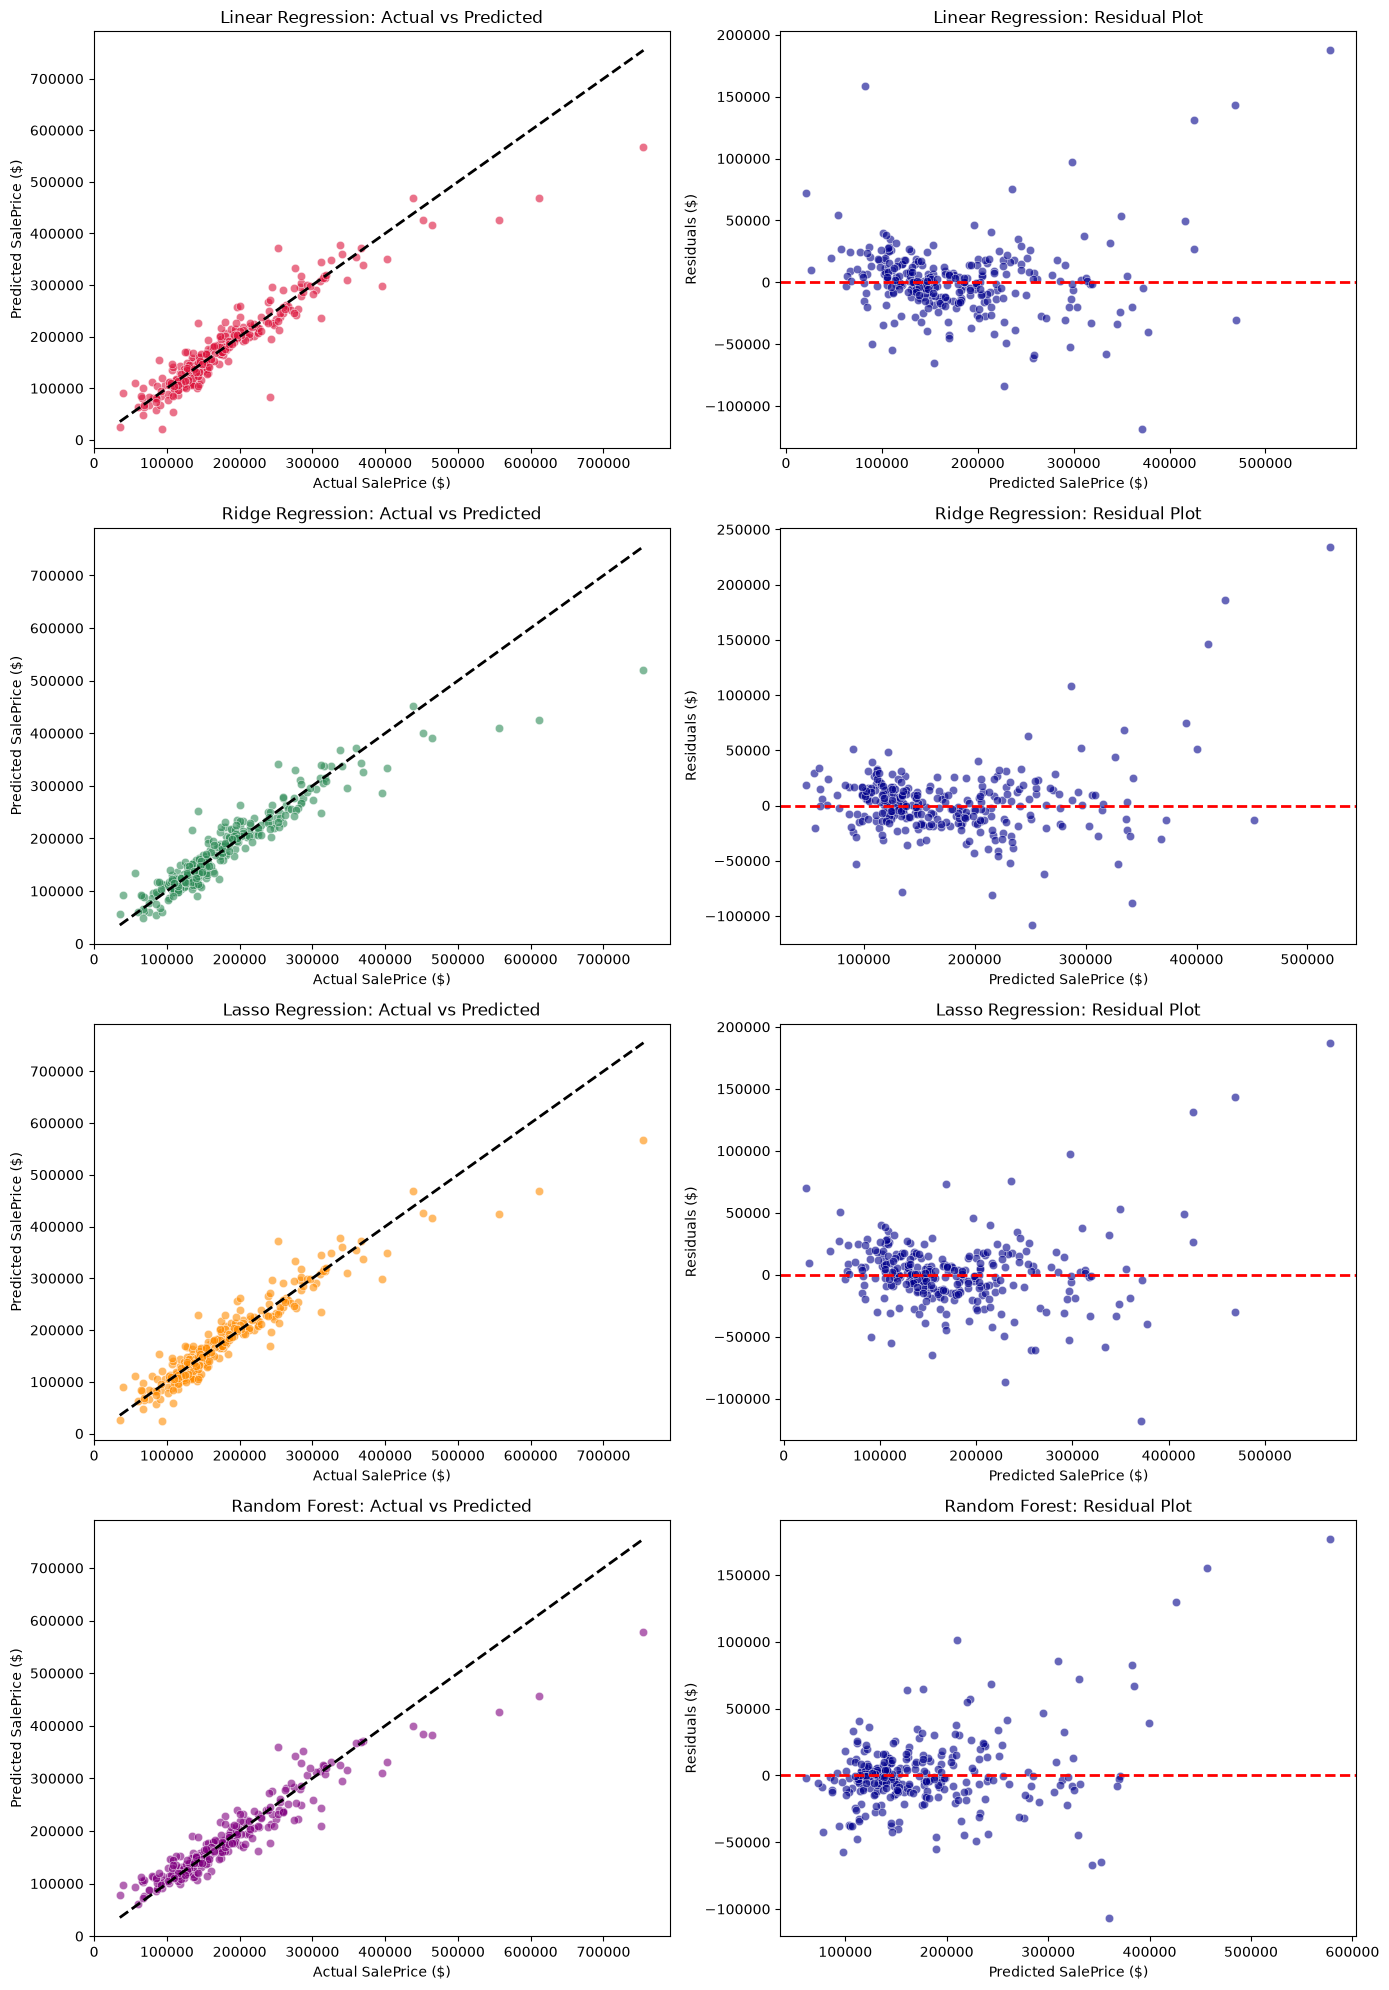

In [70]:
# Melakukan Model Evaluation
print("\n=== Evaluasi Detail Setiap Model ===")
for name in models.keys():
    preds = predictions[name]
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"\n--- {name} ---")
    print(f"MAE      : ${mae:,.2f}")
    print(f"RMSE     : ${rmse:,.2f}")
    print(f"R2 Score : {r2:.4f}")

# Membuat Visualisasi Actual vs Predicted & Residual Plot untuk SEMUA Model Grid (2x4)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 20))
colors = ["crimson", "seagreen", "darkorange", "purple"]

for idx, (name, preds) in enumerate(predictions.items()):
    residuals = y_test - preds
    
    # Actual vs Predicted Plot
    sns.scatterplot(x=y_test, y=preds, alpha=0.6, color=colors[idx], ax=axes[idx, 0])
    axes[idx, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
    axes[idx, 0].set_title(f"{name}: Actual vs Predicted")
    axes[idx, 0].set_xlabel("Actual SalePrice ($)")
    axes[idx, 0].set_ylabel("Predicted SalePrice ($)")
    
    # Residual Plot
    sns.scatterplot(x=preds, y=residuals, alpha=0.6, color="darkblue", ax=axes[idx, 1])
    axes[idx, 1].axhline(0, color="red", linestyle="--", lw=2)
    axes[idx, 1].set_title(f"{name}: Residual Plot")
    axes[idx, 1].set_xlabel("Predicted SalePrice ($)")
    axes[idx, 1].set_ylabel("Residuals ($)")

plt.tight_layout()
plt.show()